# Analyse de données : classification par proximité et K-means

Ce notebook étudie deux méthodes de regroupement de points tridimensionnels :

1. l'affectation de chaque point au centre prédéfini le plus proche ;
2. l'estimation automatique des centres avec l'algorithme K-means.

L'objectif est de présenter une implémentation vectorisée, reproductible et directement réutilisable. Les données sont synthétiques afin que le notebook puisse être exécuté sans fichier externe.


In [11]:
from __future__ import annotations

from collections.abc import Sequence
import os

# Évite un avertissement MKL connu sous Windows pour les petits jeux de données.
os.environ.setdefault("OMP_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42


## 1. Jeu de données reproductible

`make_blobs` crée trois groupes dont les centres réels sont connus. On peut ainsi vérifier visuellement et quantitativement les résultats de l'algorithme.


In [12]:
TRUE_CENTERS = np.array(
    [
        [-55.0, 45.0, -35.0],
        [10.0, -55.0, 30.0],
        [60.0, 35.0, 55.0],
    ]
)

points, true_labels = make_blobs(
    n_samples=150,
    centers=TRUE_CENTERS,
    cluster_std=[13.0, 16.0, 12.0],
    n_features=3,
    random_state=RANDOM_STATE,
)

points_frame = pd.DataFrame(points, columns=["x", "y", "z"])
points_frame["true_cluster"] = true_labels
points_frame.head()


,x,y,z,true_cluster
0,20.980163,-80.803454,22.449090,1
1,53.235305,25.133355,57.924247,2
2,48.721443,28.833597,42.289438,2
3,57.573688,32.387826,68.185322,2
4,-53.807110,19.161604,-37.855735,0


## 2. Affectation au centre le plus proche

Pour un point $x_i$ et un centre $c_j$, la distance euclidienne est

$$d(x_i, c_j) = \sqrt{\sum_k (x_{ik} - c_{jk})^2}.$$

Le *broadcasting* NumPy calcule toutes les distances sans boucle Python sur les points. La fonction accepte un tableau de forme `(nombre_de_points, dimensions)` et un tableau de centres partageant le même nombre de dimensions.


In [13]:
def assign_to_nearest_center(
    points: np.ndarray,
    centers: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Retourne le centre le plus proche et sa distance pour chaque point."""
    point_array = np.asarray(points, dtype=float)
    center_array = np.asarray(centers, dtype=float)

    if point_array.ndim != 2 or center_array.ndim != 2:
        raise ValueError("points et centers doivent être des matrices bidimensionnelles")
    if point_array.shape[1] != center_array.shape[1]:
        raise ValueError("Les points et les centres doivent avoir la même dimension")
    if len(center_array) == 0:
        raise ValueError("Au moins un centre est requis")
    if not np.isfinite(point_array).all() or not np.isfinite(center_array).all():
        raise ValueError("Les coordonnées doivent être finies")

    differences = point_array[:, np.newaxis, :] - center_array[np.newaxis, :, :]
    distances = np.linalg.norm(differences, axis=2)
    nearest_indices = distances.argmin(axis=1)
    nearest_distances = distances[np.arange(len(point_array)), nearest_indices]
    return nearest_indices, nearest_distances


assigned_labels, assigned_distances = assign_to_nearest_center(points, TRUE_CENTERS)

manual_assignment = points_frame.assign(
    assigned_cluster=assigned_labels,
    distance_to_center=assigned_distances,
)
manual_assignment.head()


,x,y,z,true_cluster,assigned_cluster,distance_to_center
0,20.980163,-80.803454,22.449090,1,1,29.041323
1,53.235305,25.133355,57.924247,2,2,12.315153
2,48.721443,28.833597,42.289438,2,2,18.077300
3,57.573688,32.387826,68.185322,2,2,13.658813
4,-53.807110,19.161604,-37.855735,0,0,26.023084


In [14]:
assignment_summary = (
    manual_assignment.groupby("assigned_cluster", as_index=False)
    .agg(
        point_count=("assigned_cluster", "size"),
        mean_distance=("distance_to_center", "mean"),
        max_distance=("distance_to_center", "max"),
    )
)
assignment_summary


,assigned_cluster,point_count,mean_distance,max_distance
0,0,50,19.912907,39.671216
1,1,50,25.451768,62.733040
2,2,50,18.068550,35.296594


## 3. Estimation des centres avec K-means

Contrairement à l'affectation précédente, K-means ne reçoit pas les centres réels. Il les estime en minimisant la somme des distances quadratiques entre les points et leur centre de cluster.

Le paramètre `random_state` rend le résultat reproductible. `n_init` fixe explicitement le nombre d'initialisations afin d'éviter une dépendance à la valeur par défaut de la version installée de scikit-learn.


In [15]:
def fit_kmeans(
    points: np.ndarray,
    *,
    n_clusters: int,
    random_state: int = RANDOM_STATE,
) -> tuple[KMeans, np.ndarray]:
    """Ajuste un modèle K-means après validation des données."""
    point_array = np.asarray(points, dtype=float)
    if point_array.ndim != 2:
        raise ValueError("points doit être une matrice bidimensionnelle")
    if not 2 <= n_clusters < len(point_array):
        raise ValueError("n_clusters doit être compris entre 2 et n_samples - 1")
    if not np.isfinite(point_array).all():
        raise ValueError("Les coordonnées doivent être finies")

    model = KMeans(
        n_clusters=n_clusters,
        n_init=20,
        random_state=random_state,
    )
    labels = model.fit_predict(point_array)
    return model, labels


kmeans_model, predicted_labels = fit_kmeans(points, n_clusters=3)

model_summary = pd.Series(
    {
        "clusters": kmeans_model.n_clusters,
        "inertia": kmeans_model.inertia_,
        "silhouette_score": silhouette_score(points, predicted_labels),
        "iterations": kmeans_model.n_iter_,
    },
    name="KMeans",
)
model_summary


clusters                3.000000
inertia             79386.799969
silhouette_score        0.747448
iterations              2.000000
Name: KMeans, dtype: float64

In [16]:
estimated_centers = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns=["x", "y", "z"],
)
estimated_centers.index.name = "cluster"
estimated_centers


,x,y,z
cluster,,,
0,13.679644,-59.084361,33.823745
1,-55.603796,43.554477,-36.161430
2,60.403590,34.969835,56.605808


## 4. Choix du nombre de clusters

L'inertie diminue mécaniquement lorsque le nombre de clusters augmente ; elle ne suffit donc pas à elle seule. Le score de silhouette complète l'analyse : une valeur élevée indique des groupes compacts et bien séparés.


In [17]:
def evaluate_cluster_counts(
    points: np.ndarray,
    candidates: Sequence[int],
    *,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    """Compare l'inertie et le score de silhouette de plusieurs modèles."""
    rows = []
    for n_clusters in candidates:
        model, labels = fit_kmeans(
            points,
            n_clusters=n_clusters,
            random_state=random_state,
        )
        rows.append(
            {
                "n_clusters": n_clusters,
                "inertia": model.inertia_,
                "silhouette_score": silhouette_score(points, labels),
            }
        )
    return pd.DataFrame(rows).set_index("n_clusters")


cluster_evaluation = evaluate_cluster_counts(points, candidates=range(2, 7))
cluster_evaluation


,inertia,silhouette_score
n_clusters,,
2,368095.332509,0.612768
3,79386.799969,0.747448
4,67581.406951,0.609422
5,60864.069110,0.436611
6,55364.925241,0.423293


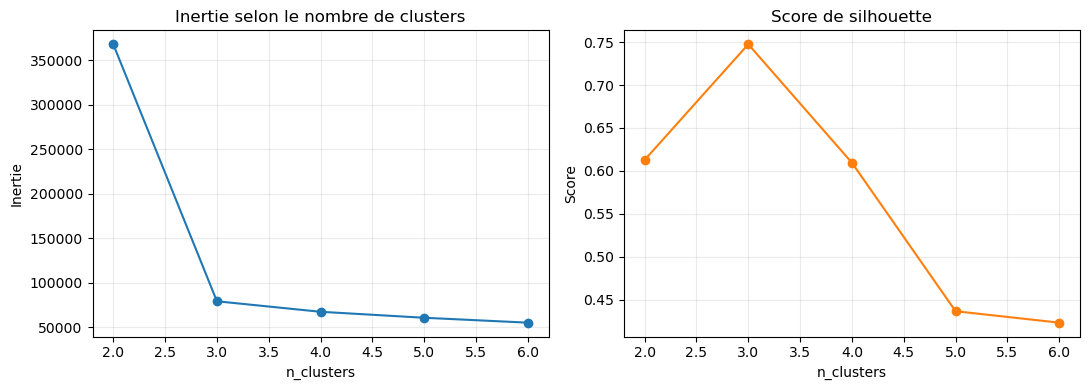

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cluster_evaluation["inertia"].plot(
    ax=axes[0], marker="o", title="Inertie selon le nombre de clusters"
)
axes[0].set_ylabel("Inertie")
axes[0].grid(alpha=0.25)

cluster_evaluation["silhouette_score"].plot(
    ax=axes[1], marker="o", color="tab:orange",
    title="Score de silhouette",
)
axes[1].set_ylabel("Score")
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()


## 5. Visualisation tridimensionnelle

Les points sont colorés selon le cluster estimé. Les croix noires représentent les centres appris par K-means.


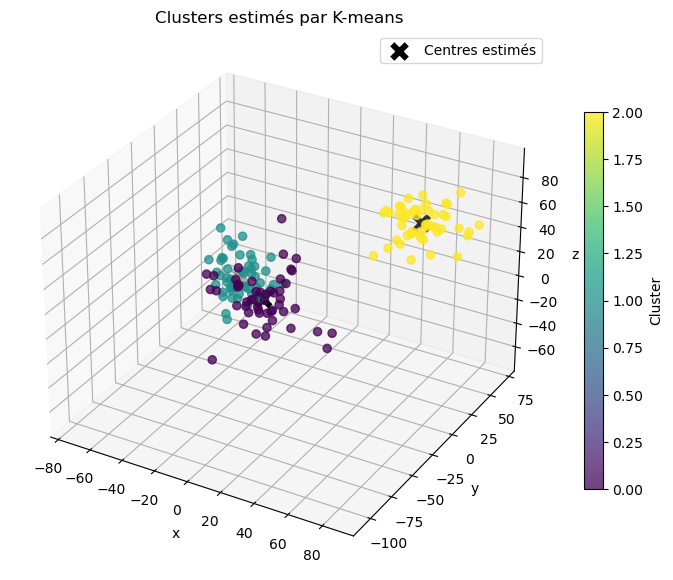

In [19]:
def plot_clusters_3d(
    points: np.ndarray,
    labels: np.ndarray,
    centers: np.ndarray,
) -> None:
    """Affiche des points 3D et les centres associés."""
    point_array = np.asarray(points, dtype=float)
    center_array = np.asarray(centers, dtype=float)
    label_array = np.asarray(labels)

    if point_array.ndim != 2 or point_array.shape[1] != 3:
        raise ValueError("La visualisation nécessite des points en trois dimensions")
    if center_array.ndim != 2 or center_array.shape[1] != 3:
        raise ValueError("La visualisation nécessite des centres en trois dimensions")
    if len(label_array) != len(point_array):
        raise ValueError("Un label est requis pour chaque point")

    figure = plt.figure(figsize=(9, 7))
    axis = figure.add_subplot(111, projection="3d")
    scatter = axis.scatter(
        point_array[:, 0],
        point_array[:, 1],
        point_array[:, 2],
        c=label_array,
        cmap="viridis",
        alpha=0.75,
        s=35,
    )
    axis.scatter(
        center_array[:, 0],
        center_array[:, 1],
        center_array[:, 2],
        marker="X",
        c="black",
        edgecolors="white",
        linewidths=1,
        s=220,
        label="Centres estimés",
    )
    axis.set(xlabel="x", ylabel="y", zlabel="z", title="Clusters estimés par K-means")
    axis.legend()
    figure.colorbar(scatter, ax=axis, label="Cluster", shrink=0.7)
    plt.show()


plot_clusters_3d(points, predicted_labels, kmeans_model.cluster_centers_)


## 6. Test de conformité aux captures de référence

L'exercice d'origine attend un dictionnaire qui associe le nom de chaque centre aux indices des points les plus proches. Les trois exemples ci-dessous reprennent exactement les captures. L'écart mesuré est le nombre total d'indices absents, supplémentaires ou affectés au mauvais centre.


In [20]:
def cluster_points(
    points: np.ndarray,
    cluster_centers: dict[str, list[float]],
) -> dict[str, list[int]]:
    """Associe les noms des centres aux indices de leurs points les plus proches."""
    center_names = list(cluster_centers)
    center_values = np.asarray([cluster_centers[name] for name in center_names], dtype=float)
    nearest_indices, _ = assign_to_nearest_center(points, center_values)
    return {
        center_name: np.flatnonzero(nearest_indices == center_index).tolist()
        for center_index, center_name in enumerate(center_names)
        if np.any(nearest_indices == center_index)
    }


cluster_test_cases = [
    (
        np.array([
            [18.08, 78.95, -12.73], [61.02, 34.75, -40.64], [-83.06, -27.62, -73.54],
            [78.37, -24.72, -54.40], [-2.01, -92.49, -77.56], [-25.87, 15.34, -81.73],
            [81.98, -16.00, 89.27], [-45.11, -22.49, 44.12], [-35.62, -38.43, -73.62],
            [-87.98, 54.16, -94.34],
        ]),
        {"Center1": [68.03, -77.24, 23.50], "Center2": [66.66, -22.67, -38.08], "Center3": [35.01, -72.03, 60.50]},
        {"Center2": [0, 1, 2, 3, 4, 5, 8, 9], "Center3": [6, 7]},
    ),
    (
        np.array([[-11.95, 68.14, 52.96], [-44.68, 51.80, 14.19], [4.35, 77.51, 73.96], [-6.98, 33.09, 5.83], [16.44, 56.20, 53.39]]),
        {"Center1": [-63.20, 32.15, -22.58], "Center2": [83.79, 48.71, 6.32]},
        {"Center1": [0, 1, 3], "Center2": [2, 4]},
    ),
    (
        np.array([
            [-71.76, -36.28, -34.98], [0.50, 43.86, 51.17], [83.63, -91.69, -22.52],
            [32.41, -23.72, -57.40], [2.98, -46.07, 35.87], [78.47, -71.37, 81.04],
            [13.72, 81.15, -85.99], [-89.80, -75.55, 33.54], [63.69, -76.08, 93.69],
            [-27.08, 11.32, -17.20],
        ]),
        {"Center1": [-43.97, 55.37, 9.15], "Center2": [75.30, -18.25, 16.04], "Center3": [-32.18, -87.45, 1.10], "Center4": [-39.56, -13.19, -71.81]},
        {"Center1": [1, 9], "Center2": [2, 5, 8], "Center3": [4, 7], "Center4": [0, 3, 6]},
    ),
]


def assignment_difference(actual: dict[str, list[int]], expected: dict[str, list[int]]) -> int:
    """Compte les indices différents pour chaque centre des deux résultats."""
    center_names = set(actual) | set(expected)
    return sum(
        len(set(actual.get(name, [])) ^ set(expected.get(name, [])))
        for name in center_names
    )


cluster_results = []
for case_number, (test_points, test_centers, expected) in enumerate(cluster_test_cases, start=1):
    actual = cluster_points(test_points, test_centers)
    difference = assignment_difference(actual, expected)
    cluster_results.append({
        "case": case_number,
        "assignment_difference": difference,
        "status": "OK" if difference == 0 else "ÉCHEC",
    })

cluster_conformance_report = pd.DataFrame(cluster_results).set_index("case")
cluster_conformance_report


,assignment_difference,status
case,,
1,0,OK
2,0,OK
3,0,OK


In [21]:
assert (cluster_conformance_report["assignment_difference"] == 0).all(), cluster_conformance_report
print("Les trois affectations correspondent exactement aux captures de référence.")


Les trois affectations correspondent exactement aux captures de référence.


## 7. Contrôles de cohérence

Ces assertions vérifient les propriétés essentielles du résultat. Dans un projet, elles pourront être déplacées vers une suite de tests automatisés.


In [22]:
assert assigned_labels.shape == (len(points),)
assert assigned_distances.shape == (len(points),)
assert np.all(assigned_distances >= 0)
assert set(np.unique(predicted_labels)) == {0, 1, 2}
assert kmeans_model.cluster_centers_.shape == (3, 3)
assert 0.0 <= model_summary["silhouette_score"] <= 1.0

print("Tous les contrôles de cohérence sont validés.")


Tous les contrôles de cohérence sont validés.


## Points d'attention en production

- Standardiser les variables lorsqu'elles utilisent des unités ou des échelles différentes.
- Traiter explicitement les valeurs manquantes avant l'ajustement.
- Évaluer plusieurs initialisations et plusieurs nombres de clusters.
- Ne pas interpréter les numéros de clusters comme des catégories ordonnées.
- Versionner les dépendances et conserver le modèle ajusté avec les transformations appliquées.
